# 05 — Visualization of Forecast Results

This notebook visualizes historical and forecasted water quality parameters
to support interpretation, presentation, and decision-making.


Cell 2 — Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt


Cell 3 — Paths & Config

In [2]:
PREP_DIR = "../data/prepared"
FORECAST_DIR = "../outputs/forecasts"
FIG_DIR = "../outputs/figures"

os.makedirs(FIG_DIR, exist_ok=True)

# =========================
# CONFIG
# =========================
RESOLUTION = "monthly"   # "monthly" | "weekly"
PARAMETERS = [
    "secchi",
    "chlorophyll_a",
    "tsi",
    "turbidity",
    "salinity",
    "do",
    "ph"
]


Cell 4 — Helper: Load Forecast (รองรับ index ไม่มีชื่อ)

In [3]:
def load_forecast(path):
    return pd.read_csv(
        path,
        parse_dates=[0],
        index_col=0
    )


Cell 5 — Plot Function (Single Parameter)

In [4]:
def plot_parameter(station, hist_df, fc_df, param):
    plt.figure(figsize=(10,4))

    if param in hist_df.columns:
        plt.plot(
            hist_df.index, hist_df[param],
            label="Historical", linewidth=2
        )

    if param in fc_df.columns:
        plt.plot(
            fc_df.index, fc_df[param],
            label="Forecast", linestyle="--", linewidth=2
        )

    plt.title(f"{station} — {param.replace('_',' ').title()} ({RESOLUTION})")
    plt.legend()
    plt.tight_layout()

    out = os.path.join(
        FIG_DIR, f"{station}_{param}_{RESOLUTION}.png"
    )
    plt.savefig(out)
    plt.close()


Cell 6 — Loop: Plot ALL Stations & Parameters

In [5]:
for file in os.listdir(FORECAST_DIR):
    if not file.endswith(f"{RESOLUTION}_forecast.csv"):
        continue

    station = file.replace(f"_{RESOLUTION}_forecast.csv", "")
    print(f"📊 Visualizing: {station}")

    # historical (monthly prepared)
    hist_df = pd.read_csv(
        os.path.join(PREP_DIR, f"{station}_prepared.csv"),
        parse_dates=["date"],
        index_col="date"
    )

    # forecast
    fc_df = load_forecast(
        os.path.join(FORECAST_DIR, file)
    )

    for param in PARAMETERS:
        if param in hist_df.columns and param in fc_df.columns:
            plot_parameter(station, hist_df, fc_df, param)

    print(f"✅ Saved figures for {station}")


📊 Visualizing: CP01
✅ Saved figures for CP01
📊 Visualizing: LS01
✅ Saved figures for LS01
📊 Visualizing: LS03
✅ Saved figures for LS03
📊 Visualizing: PN01
✅ Saved figures for PN01
📊 Visualizing: SK01
✅ Saved figures for SK01
📊 Visualizing: SK06
✅ Saved figures for SK06
📊 Visualizing: TP011
✅ Saved figures for TP011
📊 Visualizing: TP01
✅ Saved figures for TP01
📊 Visualizing: TP04
✅ Saved figures for TP04


Cell 7 — Example Preview (Optional)

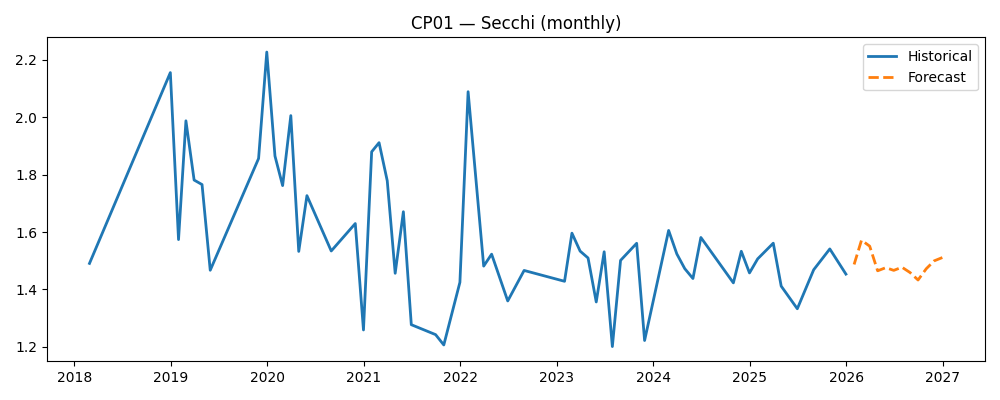

In [6]:
from IPython.display import Image, display

display(Image(filename="../outputs/figures/CP01_secchi_monthly.png"))
